# SALAM KENAL KAMI DARI J-TEAM

# 1. Import Dataset Dari Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


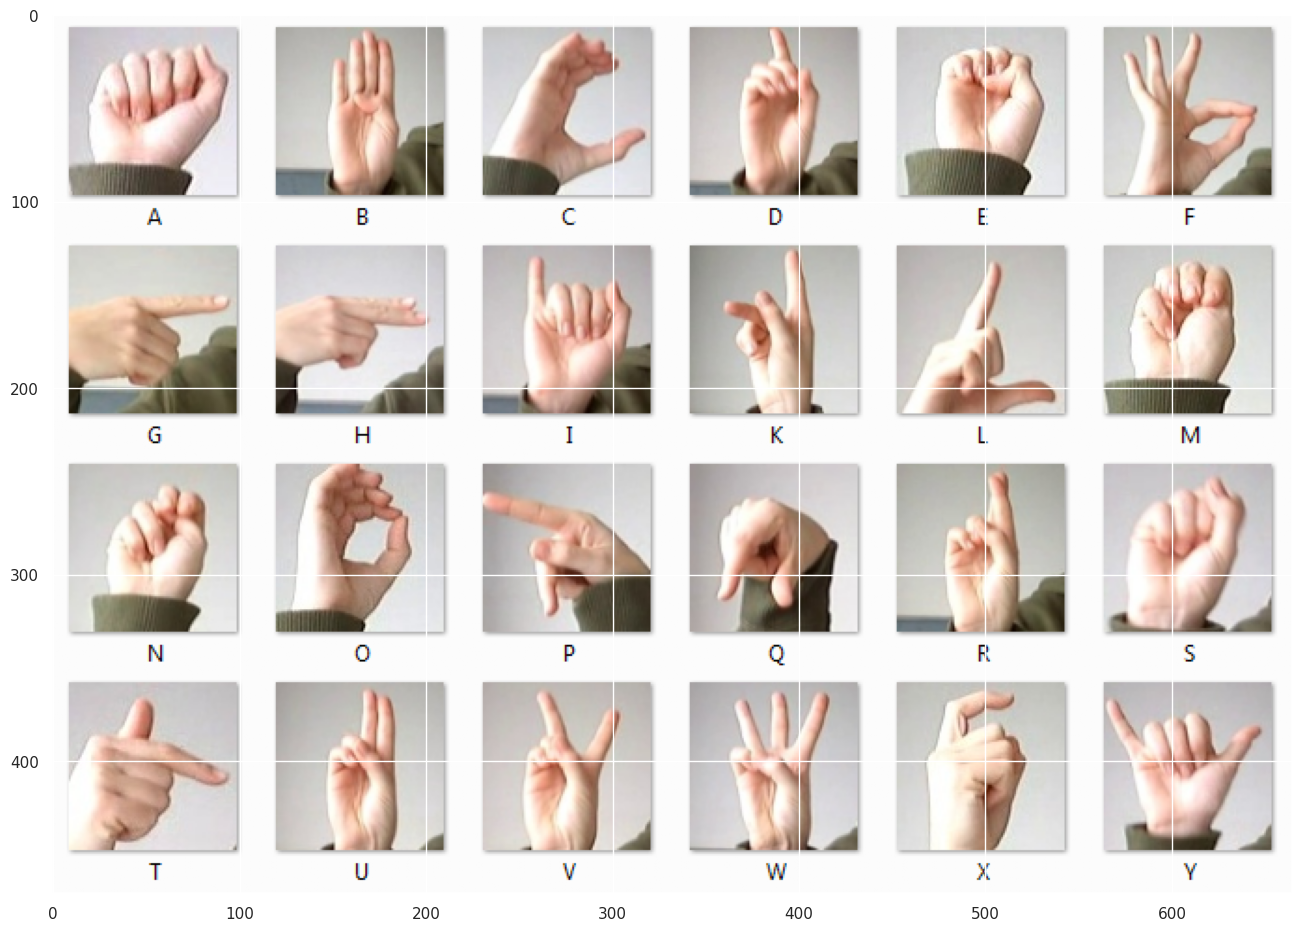

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import drive
drive.mount('/content/drive')

# Ganti path ini dengan path yang benar ke file gambar Anda di Google Drive
image_path = '/content/drive/My Drive/TugasBesarDL/Dataset/amer_sign2.png'

plt.figure(figsize = (16,16))
img = mpimg.imread(image_path)
plt.imshow(img)
plt.show()

Dataset ini disusun mirip dengan MNIST standar, dengan setiap contoh pelatihan dan pengujian mewakili huruf A-Z (kecuali J dan Z) melalui label angka 0-25. Data pelatihan (27.455 kasus) dan data pengujian (7172 kasus) berukuran sekitar setengah dari MNIST standar. Setiap kasus terdiri dari label dan 784 nilai piksel yang membentuk gambar skala abu-abu 28x28.

# 2. Import library
Pertama, kita impor library yang akan kita butuhkan.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Flatten, Dense, Dropout
import warnings

sns.set()
%matplotlib inline
warnings.filterwarnings("ignore")

# 3- Prepare Data
Impor data train dan test sebagai dataframe.

In [ ]:
df_train = pd.read_csv('/content/drive/My Drive/TugasBesarDL/Dataset/sign_mnist_train/sign_mnist_train.csv')
df_train.head(-5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27445,14,167,169,170,171,171,172,172,172,171,...,215,215,211,208,211,201,167,119,75,48
27446,19,133,135,138,141,143,144,144,145,145,...,0,0,1,4,4,0,0,0,0,0
27447,11,170,172,175,177,179,182,185,186,187,...,221,228,229,228,229,229,227,228,227,227
27448,12,149,151,153,157,159,161,164,165,168,...,108,165,167,163,159,153,147,148,139,196


In [ ]:
df_test = pd.read_csv('/content/drive/My Drive/TugasBesarDL/Dataset/sign_mnist_train/sign_mnist_train.csv')
df_test.head(-5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27445,14,167,169,170,171,171,172,172,172,171,...,215,215,211,208,211,201,167,119,75,48
27446,19,133,135,138,141,143,144,144,145,145,...,0,0,1,4,4,0,0,0,0,0
27447,11,170,172,175,177,179,182,185,186,187,...,221,228,229,228,229,229,227,228,227,227
27448,12,149,151,153,157,159,161,164,165,168,...,108,165,167,163,159,153,147,148,139,196


Kelas data dan jumlah gambarnya.

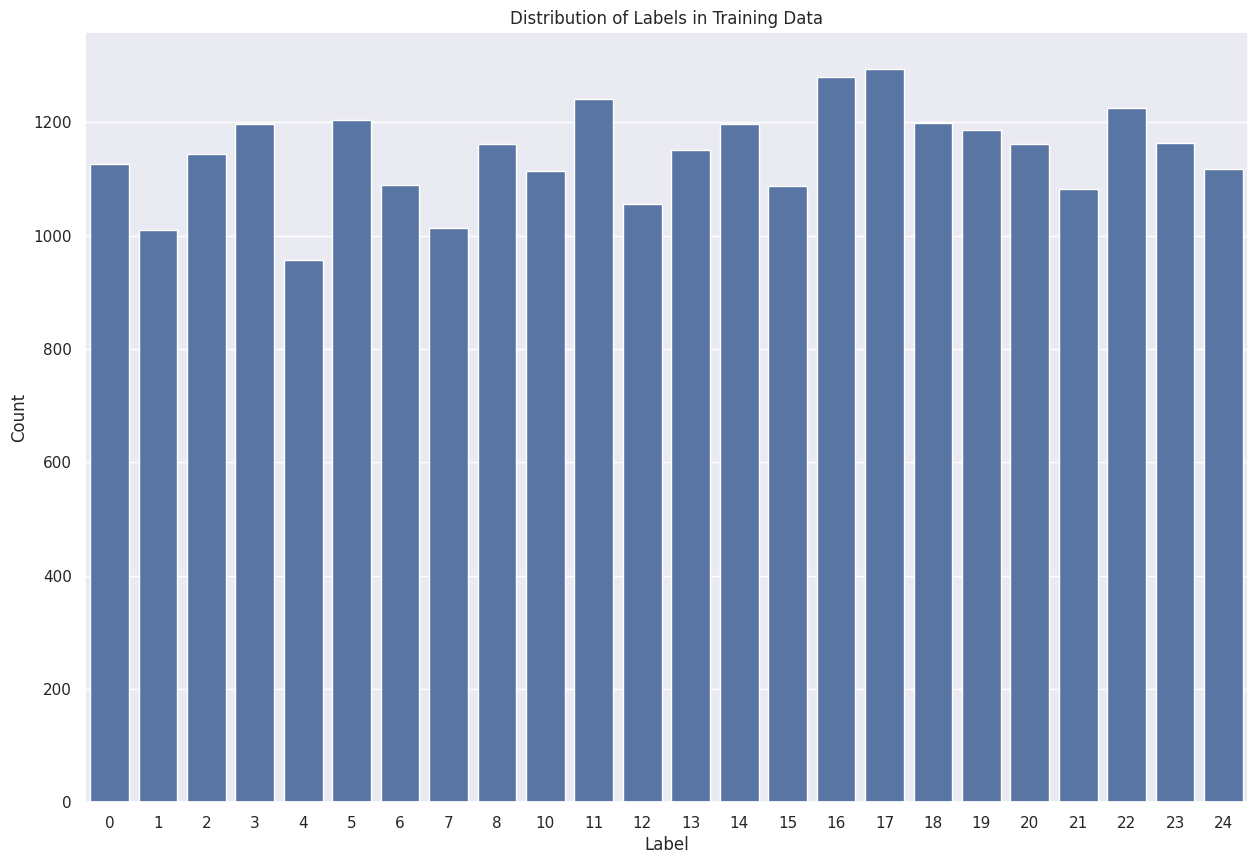

In [ ]:
plt.figure(figsize=(15, 10))
sns.set_style("darkgrid")
sns.countplot(x=y_train)
plt.title("Distribution of Labels in Training Data")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

Mari kita pisahkan kolom label dari dataframe train dan test.

In [ ]:
if 'label' in df_train.columns:
    y_train = df_train['label']
    df_train.drop(['label'], axis=1, inplace=True)
df_train.head(-5)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,107,118,127,134,139,143,146,150,153,156,...,207,207,207,207,206,206,206,204,203,202
1,155,157,156,156,156,157,156,158,158,157,...,69,149,128,87,94,163,175,103,135,149
2,187,188,188,187,187,186,187,188,187,186,...,202,201,200,199,198,199,198,195,194,195
3,211,211,212,212,211,210,211,210,210,211,...,235,234,233,231,230,226,225,222,229,163
4,164,167,170,172,176,179,180,184,185,186,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27445,167,169,170,171,171,172,172,172,171,172,...,215,215,211,208,211,201,167,119,75,48
27446,133,135,138,141,143,144,144,145,145,145,...,0,0,1,4,4,0,0,0,0,0
27447,170,172,175,177,179,182,185,186,187,188,...,221,228,229,228,229,229,227,228,227,227
27448,149,151,153,157,159,161,164,165,168,171,...,108,165,167,163,159,153,147,148,139,196


In [ ]:
if 'label' in df_test.columns:
    y_test = df_test['label']
    df_test.drop(['label'], axis=1, inplace=True)
df_test.head(-5)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,107,118,127,134,139,143,146,150,153,156,...,207,207,207,207,206,206,206,204,203,202
1,155,157,156,156,156,157,156,158,158,157,...,69,149,128,87,94,163,175,103,135,149
2,187,188,188,187,187,186,187,188,187,186,...,202,201,200,199,198,199,198,195,194,195
3,211,211,212,212,211,210,211,210,210,211,...,235,234,233,231,230,226,225,222,229,163
4,164,167,170,172,176,179,180,184,185,186,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27445,167,169,170,171,171,172,172,172,171,172,...,215,215,211,208,211,201,167,119,75,48
27446,133,135,138,141,143,144,144,145,145,145,...,0,0,1,4,4,0,0,0,0,0
27447,170,172,175,177,179,182,185,186,187,188,...,221,228,229,228,229,229,227,228,227,227
27448,149,151,153,157,159,161,164,165,168,171,...,108,165,167,163,159,153,147,148,139,196


Definisikan ukuran gambar dan salurannya, ukuran batch, dan jumlah epoch.

In [ ]:
size  = 28
channels = 1
batch = 128
epochs = 100

Ubah bentuk data untuk menyiapkan gambar untuk ImageDataGenerator:

reshape(jumlah baris, lebar gambar, tinggi gambar, saluran)"

In [ ]:
X_train = df_train.values.reshape(df_train.shape[0], size, size, channels)
X_test = df_test.values.reshape(df_test.shape[0], size, size, channels)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (27455, 28, 28, 1)
X_test shape: (27455, 28, 28, 1)


# 4- Data Augmentation
Mari kita lakukan augmentasi pada data training dan hanya penskalaan pada data validasi dan test.

In [ ]:
datagen = ImageDataGenerator(rescale=1./255,
                             zoom_range=0.2,
                             width_shift_range=.2, height_shift_range=.2,
                             rotation_range=30,
                             brightness_range=[0.8, 1.2],
                             horizontal_flip=True)

datagenRescale = ImageDataGenerator(rescale=1./255)

X_train = datagen.flow(X_train, y_train, batch_size=batch)

X_test = datagenRescale.flow(X_test, y_test)

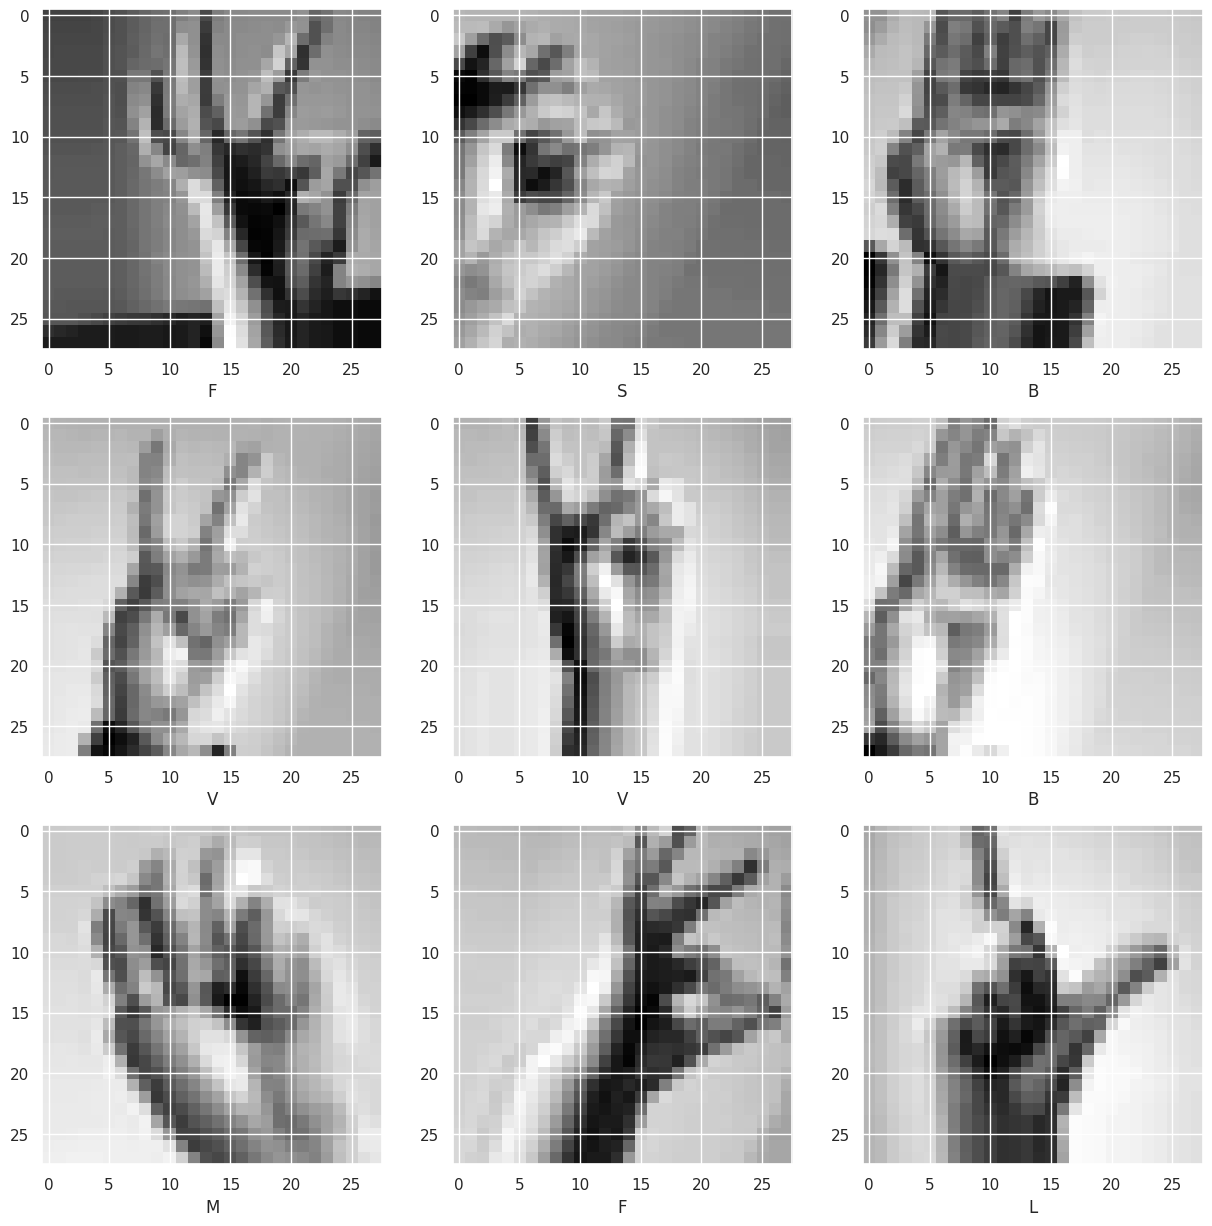

In [ ]:
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
plt.figure(figsize=(15, 15))
for i in range(9):
    plt.subplot(3, 3, i+1)
    for X_batch, Y_batch in X_train:
        image = X_batch[i]
        plt.imshow(image, cmap='gray')
        plt.xlabel(alphabet[Y_batch[i]])
        break
plt.show()

# 5- Mari kita lihat setup untuk callbacks. Callbacks ini digunakan selama proses pelatihan model untuk melakukan tindakan tertentu pada berbagai tahap, seperti menyimpan model terbaik atau menyesuaikan learning rate

In [ ]:
checkpoint_filepath = 'best_model.keras'

callback_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, save_weights_only=False, monitor='val_accuracy', mode='max', save_best_only=True)
callback_learningrate = ReduceLROnPlateau(monitor='loss', mode='min', min_delta=0.01, patience=3, factor=.75, min_lr=0.00001, verbose=1)

callbacks = [callback_checkpoint, callback_learningrate]

# 6- Mari kita lihat desain arsitektur jaringan saraf tiruan. Sel di bawah ini mendefinisikan model Sequential dengan beberapa layer Convolutional, MaxPooling, Dropout, Flatten, dan Dense. Ini adalah arsitektur umum untuk tugas klasifikasi gambar.



In [ ]:
Model = Sequential([Conv2D(filters=32,  kernel_size=(3,3), activation="relu", input_shape=(size,size,channels)),
                    MaxPool2D(2,2, padding='same'),
                    Dropout(0.2),

                    Conv2D(filters=128,  kernel_size=(3,3), activation="relu"),
                    MaxPool2D(2,2, padding='same'),
                    Dropout(0.2),

                    Conv2D(filters=512, kernel_size=(3,3), activation="relu"),
                    MaxPool2D(2,2, padding='same'),
                    Dropout(0.2),


                    Flatten(),

                    Dense(units=4096, activation="relu"),
                    Dropout(0.2),

                    Dense(units=1024, activation="relu"),
                    Dropout(0.2),

                    Dense(units=256, activation="relu"),
                    Dropout(0.2),

                    Dense(units=25, activation="softmax"),
])


Model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])


Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 512)      │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,484,505 (51.44 MB)

 Trainable params: 13,484,505 (51.44 MB)

 Non-trainable params: 0 (0.00 B)

# 7- Mari kita mulai proses pelatihan model

In [ ]:
history = Model.fit(X_train, validation_data=X_test, epochs=epochs, callbacks=callbacks)

Epoch 1/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 39s 129ms/step - accuracy: 0.0466 - loss: 3.1866 - val_accuracy: 0.1159 - val_loss: 2.7792 - learning_rate: 0.0010
Epoch 2/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.1561 - loss: 2.6359 - val_accuracy: 0.4775 - val_loss: 1.4937 - learning_rate: 0.0010
Epoch 3/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.3763 - loss: 1.8234 - val_accuracy: 0.6777 - val_loss: 0.8602 - learning_rate: 0.0010
Epoch 4/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.5456 - loss: 1.2998 - val_accuracy: 0.8166 - val_loss: 0.4928 - learning_rate: 0.0010
Epoch 5/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.6443 - loss: 1.0305 - val_accuracy: 0.9066 - val_loss: 0.2706 - learning_rate: 0.0010
Epoch 6/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.7039 - loss: 0.8500 - val_accuracy: 0.8974 - val_loss: 0.2661 - learning_rate: 0.0010
Epoch 7/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0

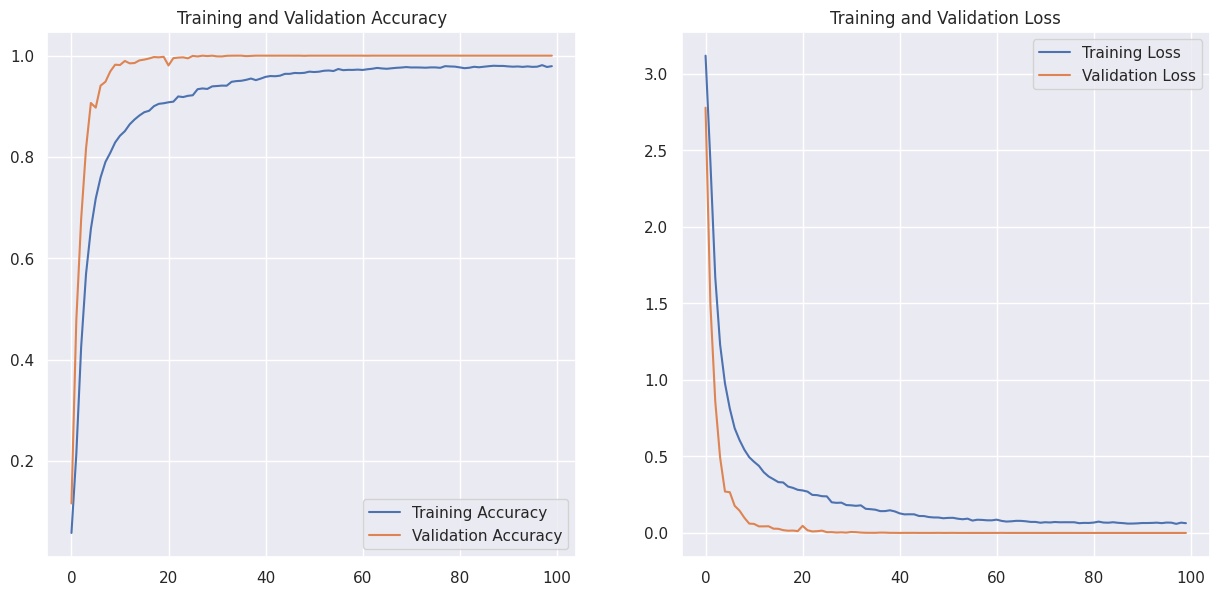

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# 8- Mari kita evaluasi performa model yang sudah dilatih

In [ ]:
score = Model.evaluate(X_test)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 1.0000 - loss: 1.9652e-04
Test loss: 0.00028520796331577003
Test accuracy: 1.0


# 9- Confusion Matrix

In [ ]:
df_test = pd.read_csv('/content/drive/My Drive/TugasBesarDL/Dataset/sign_mnist_test/sign_mnist_test.csv')
y_test = df_test['label']
df_test.drop(['label'], axis=1, inplace=True)
X_test = df_test.values.reshape(df_test.shape[0], size, size, channels)

In [ ]:
y_pred = np.argmax(Model.predict(X_test),axis = 1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


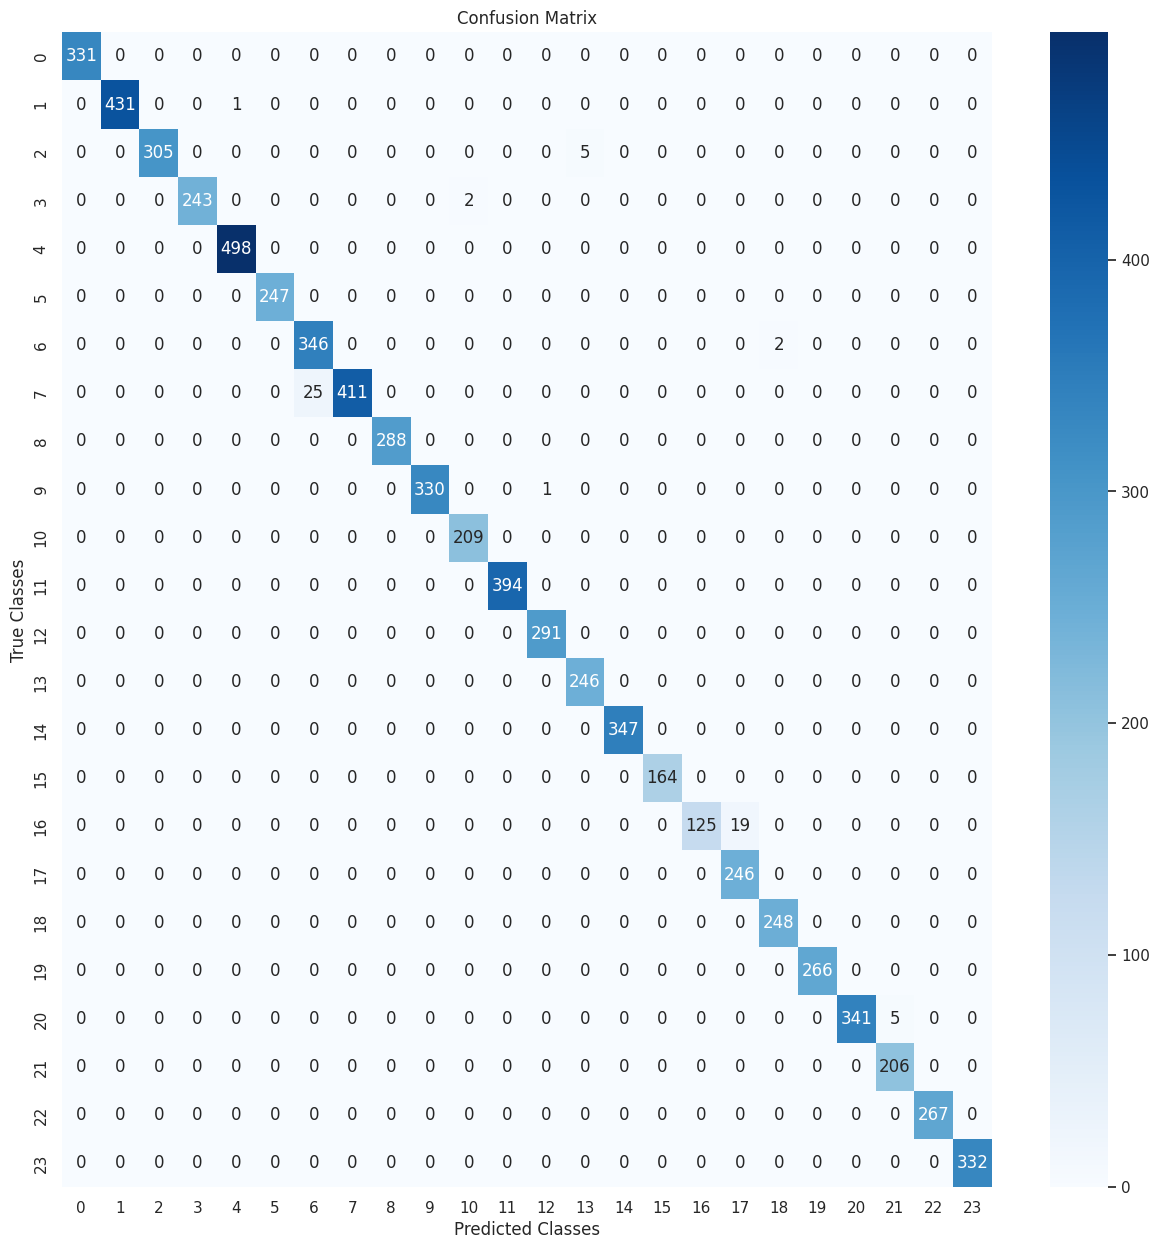

In [ ]:
from sklearn.metrics import confusion_matrix
CM = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (15,15))
sns.heatmap(CM, annot=True, cmap="Blues", fmt = 'g')
plt.xlabel("Predicted Classes")
plt.ylabel("True Classes")
plt.title("Confusion Matrix")
plt.show()

# 10- Mari kita lihat bagaimana performa model dalam memprediksi beberapa contoh dari data uji

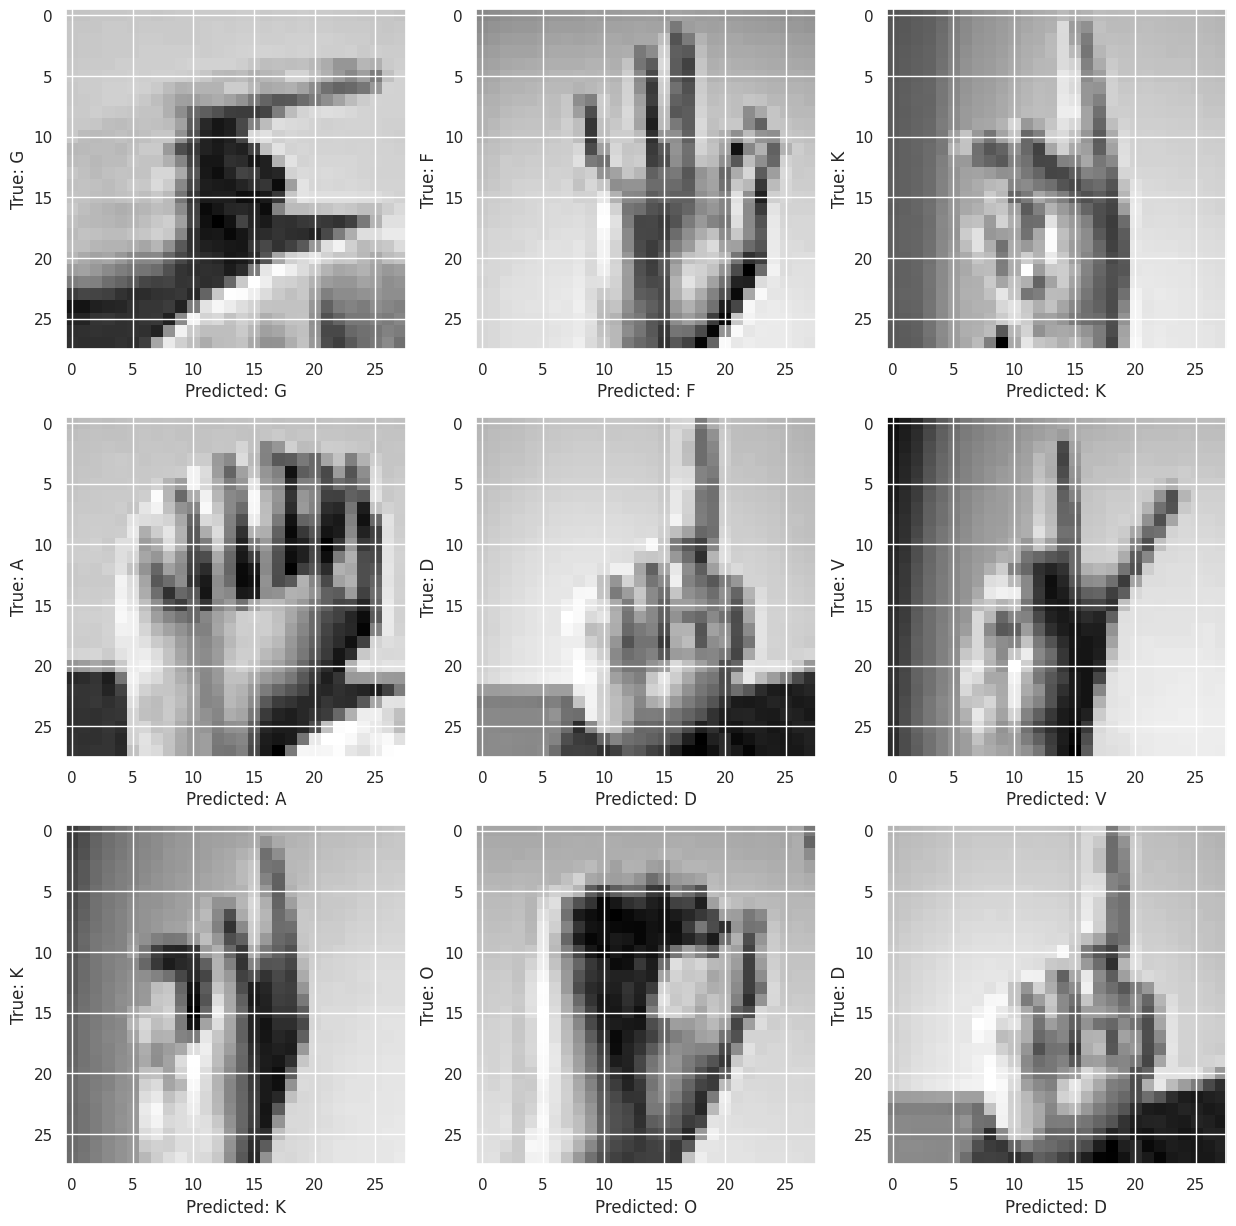

In [ ]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i],cmap='gray')

    plt.ylabel(f"True: {alphabet[y_test[i]]}")
    plt.xlabel(f"Predicted: {alphabet[y_pred[i]]}")

plt.show()

Penjelasan input output

1. Input penelitian ini adalah:

* Gambar-gambar skala abu-abu berukuran 28x28 piksel yang merepresentasikan huruf A-Z (kecuali J dan Z) dalam Bahasa Isyarat Amerika. Setiap gambar diwakili oleh 784 nilai piksel.

2. Output penelitian ini adalah:

* Prediksi label angka (0-25) yang sesuai dengan huruf Bahasa Isyarat Amerika yang direpresentasikan dalam gambar input. Model ini mengklasifikasikan setiap gambar ke dalam salah satu dari 25 kelas huruf.